# Research Assistant

In [27]:
# from dotenv import load_dotenv
# load_dotenv(override=True)

In [28]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

## Setup

In [29]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [30]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model='gpt-4o-mini',temperature=0)

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [31]:
from typing_extensions import TypedDict
from pydantic import BaseModel,Field
from IPython.display import Image, display

class Analyst(BaseModel):
    affiliation:str=Field(
        description='Primary affiliation of the analyst'
    )
    name:str=Field(
        description='Name of the analyst'
    )
    role:str=Field(
        description='Role of the analyst in the context of the topic'
    )
    description:str=Field(
        description="Description of the analyst's focus, concern and motives"
    )
    @property
    def persona(self)->str:
        return (
            f"Name: {self.name}\n"
            f"Role: {self.role}\n"
            f"Affiliation: {self.affiliation}\n"
            f"Description: {self.description}\n"
        )
    
class Perspectives(BaseModel):
    analysts:list[Analyst]=Field(
        description="Comprehensive list of analysts with their roles and affiliations."
    )

class GenerateAnalystState(TypedDict):
    topic:str
    max_analysts:input
    human_analyst_feedback:str
    analysts:list[Analyst]    

In [32]:
from langgraph.graph import START,END,StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from typing_extensions import Literal

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state:GenerateAnalystState):
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback',"")
    structured_llm=llm.with_structured_output(Perspectives)
    
    system_message=analyst_instructions.format(topic=topic,max_analysts=max_analysts,human_analyst_feedback=human_analyst_feedback)
    analysts=structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content='gnerate the set of analyst')])
    # print(analysts)

    return {'analysts':analysts.analysts}

def human_feedback(state:GenerateAnalystState):
    pass
def should_continue(state:GenerateAnalystState):
    human_analyst_feedback=state.get('human_analyst_feedback',None)
    print(human_analyst_feedback)
    if human_analyst_feedback:
        return 'create_analysts'
    return END


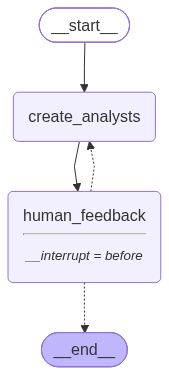

In [33]:
builder=StateGraph(GenerateAnalystState)
builder.add_node(create_analysts)
builder.add_node(human_feedback)
builder.add_edge(START,'create_analysts')
builder.add_edge('create_analysts','human_feedback')
builder.add_conditional_edges('human_feedback',should_continue,["create_analysts", END])
memory=MemorySaver()
graph=builder.compile(interrupt_before=['human_feedback'],checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [34]:
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}
for event in graph.stream({'topic':topic,'max_analysts':max_analysts},thread,stream_mode='values'):
    # print(event)
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of adopting LangGraph, emphasizing its efficiency in processing and analyzing large datasets. She is motivated by the potential for LangGraph to streamline workflows and enhance productivity in AI applications.
--------------------------------------------------
Name: Mr. James Liu
Role: Market Trends Analyst
Affiliation: Future Insights Research Group
Description: Mr. Liu examines the market implications of adopting LangGraph, particularly its competitive advantages over other frameworks. His interest lies in how businesses can leverage LangGraph to gain a strategic edge in the rapidly evolving AI landscape.
--------------------------------------------------
Name: Ms. Sarah Thompson
Role: Ethics and Sustainability Advocate
Affiliation: Sustainable Tech Solutions
Description: Ms. Thompson explores the ethical considerations and sustainabilit

In [35]:
state=graph.get_state(thread)
state.next

('human_feedback',)

In [36]:
graph.update_state(thread,{'human_analyst_feedback':'add in someone from a startup to add and interprenuer perspective '},as_node='human_feedback')

add in someone from a startup to add and interprenuer perspective 


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1871d9-cce4-6dd2-8002-ef71392da30f'}}

In [37]:
state=graph.get_state(thread)
state.next

('create_analysts',)

In [38]:
for event in graph.stream(None,thread,stream_mode='values'):
    analysts=event.get('analysts','')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-"*50)

Name: Dr. Emily Carter
Role: AI Framework Specialist
Affiliation: Tech Innovations Inc.
Description: Dr. Carter focuses on the technical advantages of adopting LangGraph, emphasizing its efficiency in processing and analyzing large datasets. She is motivated by the potential for LangGraph to streamline workflows and enhance productivity in AI applications.
--------------------------------------------------
Name: Mr. James Liu
Role: Market Trends Analyst
Affiliation: Future Insights Research Group
Description: Mr. Liu examines the market implications of adopting LangGraph, particularly its competitive advantages over other frameworks. His interest lies in how businesses can leverage LangGraph to gain a strategic edge in the rapidly evolving AI landscape.
--------------------------------------------------
Name: Ms. Sarah Thompson
Role: Ethics and Sustainability Advocate
Affiliation: Sustainable Tech Solutions
Description: Ms. Thompson explores the ethical considerations and sustainabilit

In [39]:
state=graph.get_state(thread)
state.values

{'topic': 'The benefits of adopting LangGraph as an agent framework',
 'max_analysts': 3,
 'human_analyst_feedback': 'add in someone from a startup to add and interprenuer perspective ',
 'analysts': [Analyst(affiliation='Tech Innovators Inc.', name='Alice Johnson', role='AI Framework Specialist', description='Alice focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She is particularly interested in how LangGraph can enhance AI model efficiency and scalability.'),
  Analyst(affiliation='Startup Hub', name='Michael Chen', role='Entrepreneurial Analyst', description='Michael brings a startup perspective, evaluating how LangGraph can empower new businesses to leverage AI without extensive resources. He is keen on understanding the cost-effectiveness and accessibility of LangGraph for emerging companies.'),
  Analyst(affiliation='University of Technology', name='Dr. Sarah Patel', role='Academic Researcher', des

In [40]:
graph.update_state(thread,{'human_analyst_feedback':None},as_node='human_feedback')

None


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1871d9-e384-6c18-8004-47571ecb80ff'}}

In [41]:
for event in graph.stream(None,thread,stream_mode='updates'):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [42]:
final_state=graph.get_state(thread)
analysts=final_state.values.get('analysts','')

In [43]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Role: {analyst.role}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Description: {analyst.description}")
    print("-"*50)

Name: Alice Johnson
Role: AI Framework Specialist
Affiliation: Tech Innovators Inc.
Description: Alice focuses on the technical advantages of LangGraph, analyzing its architecture and performance metrics compared to other frameworks. She is particularly interested in how LangGraph can enhance AI model efficiency and scalability.
--------------------------------------------------
Name: Michael Chen
Role: Entrepreneurial Analyst
Affiliation: Startup Hub
Description: Michael brings a startup perspective, evaluating how LangGraph can empower new businesses to leverage AI without extensive resources. He is keen on understanding the cost-effectiveness and accessibility of LangGraph for emerging companies.
--------------------------------------------------
Name: Dr. Sarah Patel
Role: Academic Researcher
Affiliation: University of Technology
Description: Dr. Patel investigates the theoretical implications of adopting LangGraph in various fields. Her research includes the impact of LangGraph on

## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [44]:
from langgraph.graph import MessagesState
from typing import Annotated
from operator import add

class InterviewState(MessagesState):
    max_num_turns:int
    context:Annotated[list[str],add]
    analyst:Analyst
    interview:str
    sections:str

class SearchQuery(BaseModel):
    search_query:str=Field(
        None,
        description='search query for retrieval'
    )
    


In [45]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

from pprint import pprint

def generate_question(state:InterviewState):
    analyst=state['analyst']
    messages=state['messages']
    system_message=question_instructions.format(goals=analyst.persona)
    question=llm.invoke([SystemMessage(content=system_message)]+messages)
    
    # pprint(question)
    return {'messages':[question]}


### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

In [46]:
from langchain_tavily import TavilySearch
tavily_search=TavilySearch(max_results=3)


In [47]:
import wikipedia

wikipedia.set_user_agent(
    "research-assistant/0.1 (you@example.com)"
)
from langchain_community.document_loaders import WikipediaLoader

/var/folders/nb/x0wcrvs97pvgcx1252s1gz700000gn/T/ipykernel_46726/3010442735.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

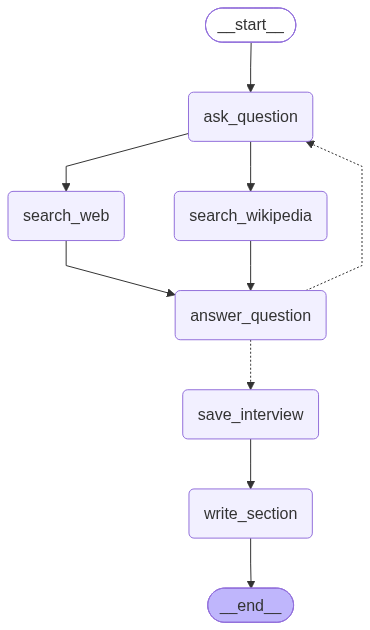

In [ ]:
from langchain_core.messages import get_buffer_string
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

def search_web(state:InterviewState):
    structure_llm=llm.with_structured_output(SearchQuery)
    search_query=structure_llm.invoke([search_instructions]+state['messages'])
    data=tavily_search.invoke({'query':search_query.search_query})
    search_docs=data.get('results',[])
    # print('*'*100)
    # print(search_docs)
    # print('#'*100)
    # search_docs = tavily_search.invoke(search_query.search_query)
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )
    return {'context':[formatted_search_docs]}

def search_wikipedia(state:InterviewState):
    structure_llm=llm.with_structured_output(SearchQuery)
    search_query=structure_llm.invoke([search_instructions]+state['messages'])
    search_docs=WikipediaLoader(query=search_query.search_query,load_max_docs=2).load()
    # print('*'*100)
    # print(search_docs)
    # print('#'*100)
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )
    return {"context": [formatted_search_docs]} 


answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answers(state:InterviewState):
    analyst=state['analyst']
    messages=state['messages']
    context=state['context']
    system_message=answer_instructions.format(goals=analyst.persona,context=context)
    answer=llm.invoke([SystemMessage(content=system_message)]+messages)
    # pprint(answer)
    answer.name='expert'
    return {'messages':[answer]}

def save_interview(state:InterviewState):
    messages=state['messages']
    interview=get_buffer_string(messages)
    return {'interview':interview}

def route_messages(state:InterviewState,name:str='expert'):
    messages=state['messages']
    max_num_turns=state.get('max_num_turns',2)
    num_response=len([m for m in messages if isinstance(m,AIMessage) and m.name==name])
    if num_response>=max_num_turns:
        return 'save_interview'
    last_question=messages[-2]
    if 'Thank you so much for your help!' in last_question.content:
        return 'save_interview'
    return 'ask_question'

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""


def write_section(state:InterviewState):
    interview=state['interview']
    context=state['context']
    analyst=state['analyst']
    system_message=section_writer_instructions.format(focus=analyst.description)
    section=llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"use this source to write your section: {context}")])
    # pprint(section)
    return {'sections':[section.content]}


interview_builder=StateGraph(InterviewState)
interview_builder.add_node('ask_question',generate_question)
interview_builder.add_node(search_web)
interview_builder.add_node(search_wikipedia)
interview_builder.add_node('answer_question',generate_answers)
interview_builder.add_node(save_interview)
interview_builder.add_node(write_section)

interview_builder.add_edge(START,'ask_question')
interview_builder.add_edge('ask_question','search_web')
interview_builder.add_edge('ask_question','search_wikipedia')
interview_builder.add_edge('search_web','answer_question')
interview_builder.add_edge('search_wikipedia','answer_question')
interview_builder.add_conditional_edges('answer_question',route_messages,['ask_question','save_interview'])
interview_builder.add_edge('save_interview','write_section')
interview_builder.add_edge('write_section',END)
memory=MemorySaver()
interview_graph=interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

display(Image(interview_graph.get_graph().draw_mermaid_png()))



